# DS1000D Rigol Waveform Examples

**Scott Prahl**

**Mar 2026**

This notebook illustrates shows how to extract signals from a `.wfm` file created by a the Rigol DS1102D scope.  

In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from RigolWFM import Wfm, DS1000D_scopes

repo = "https://github.com/scottprahl/RigolWFM/raw/main/wfm/"

In [21]:
def side_by_png(stem, ch=[1,2], offset=[0,0]):
    wfm = Wfm.from_url(repo + stem + ".wfm" + "?raw=true")
    png = iio.imread(repo + stem + ".bmp" + "?raw=true")
    
    plt.subplots(2, 1, figsize=(8,12))
    
    plt.subplot(211)
    plt.title("Rigol Screenshot")
    plt.imshow(png)
    plt.axis('off')
    
    plt.subplot(212)
    
    for channel,off in zip(ch,offset):
        chan = wfm.channels[channel-1]
        plt.plot(chan.times*1e6, chan.volts+off, label='CH%d'%channel)
    
    plt.title(stem + ".wfm (CH1 Top, CH2 Bottom)")
    plt.xlabel("Time (µs)")
    plt.ylabel("Volts (V)")
    plt.ylim(-20,20)
    plt.legend()
    plt.grid(True)

def side_by_csv(stem, ch2=True, ch2_offset=-15):
    wfm = Wfm.from_url(repo + stem + ".wfm" + "?raw=true")
    csv = np.genfromtxt(repo + stem + ".csv" + "?raw=true", delimiter=',', skip_header=2).T
    
    plt.subplots(1, 2, figsize=(12, 4.5))
    
    plt.subplot(121)

    time = csv[0]
    plt.title(stem + ".csv (CH1 Top, CH2 Bottom)")
    plt.plot(time*1e6, csv[1], color='green')
    if ch2:
        plt.plot(time*1e6, ch2_offset+csv[2], color='red')
    plt.xlabel("Time (µs)")
    plt.ylabel("Volts (V)")
    plt.grid(True)
    
    plt.subplot(122)
    
    ch1 = wfm.channels[0]
    plt.plot(ch1.times*1e6, ch1.volts, color='green')
    plt.title(stem + ".wfm (CH1 Top, CH2 Bottom)")
    if ch2:
        ch = wfm.channels[1]
        plt.plot(ch.times*1e6, ch2_offset+ch.volts, color='red')
    plt.xlabel("Time (µs)")
    plt.ylabel("Volts (V)")
    plt.grid(True)


A list of Rigol scopes in the DS1000D family is:

In [3]:
print(DS1000D_scopes[:])

['D', '1000D', 'DS1000D', 'DS1102D', 'DS1052D']


## DS1102D

We will start with a `.wfm` file from a Rigol DS1102D scope. 


### Now for the `.wfm` data

First a textual description.

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/wfm/DS1102D-A.wfm?raw=true'


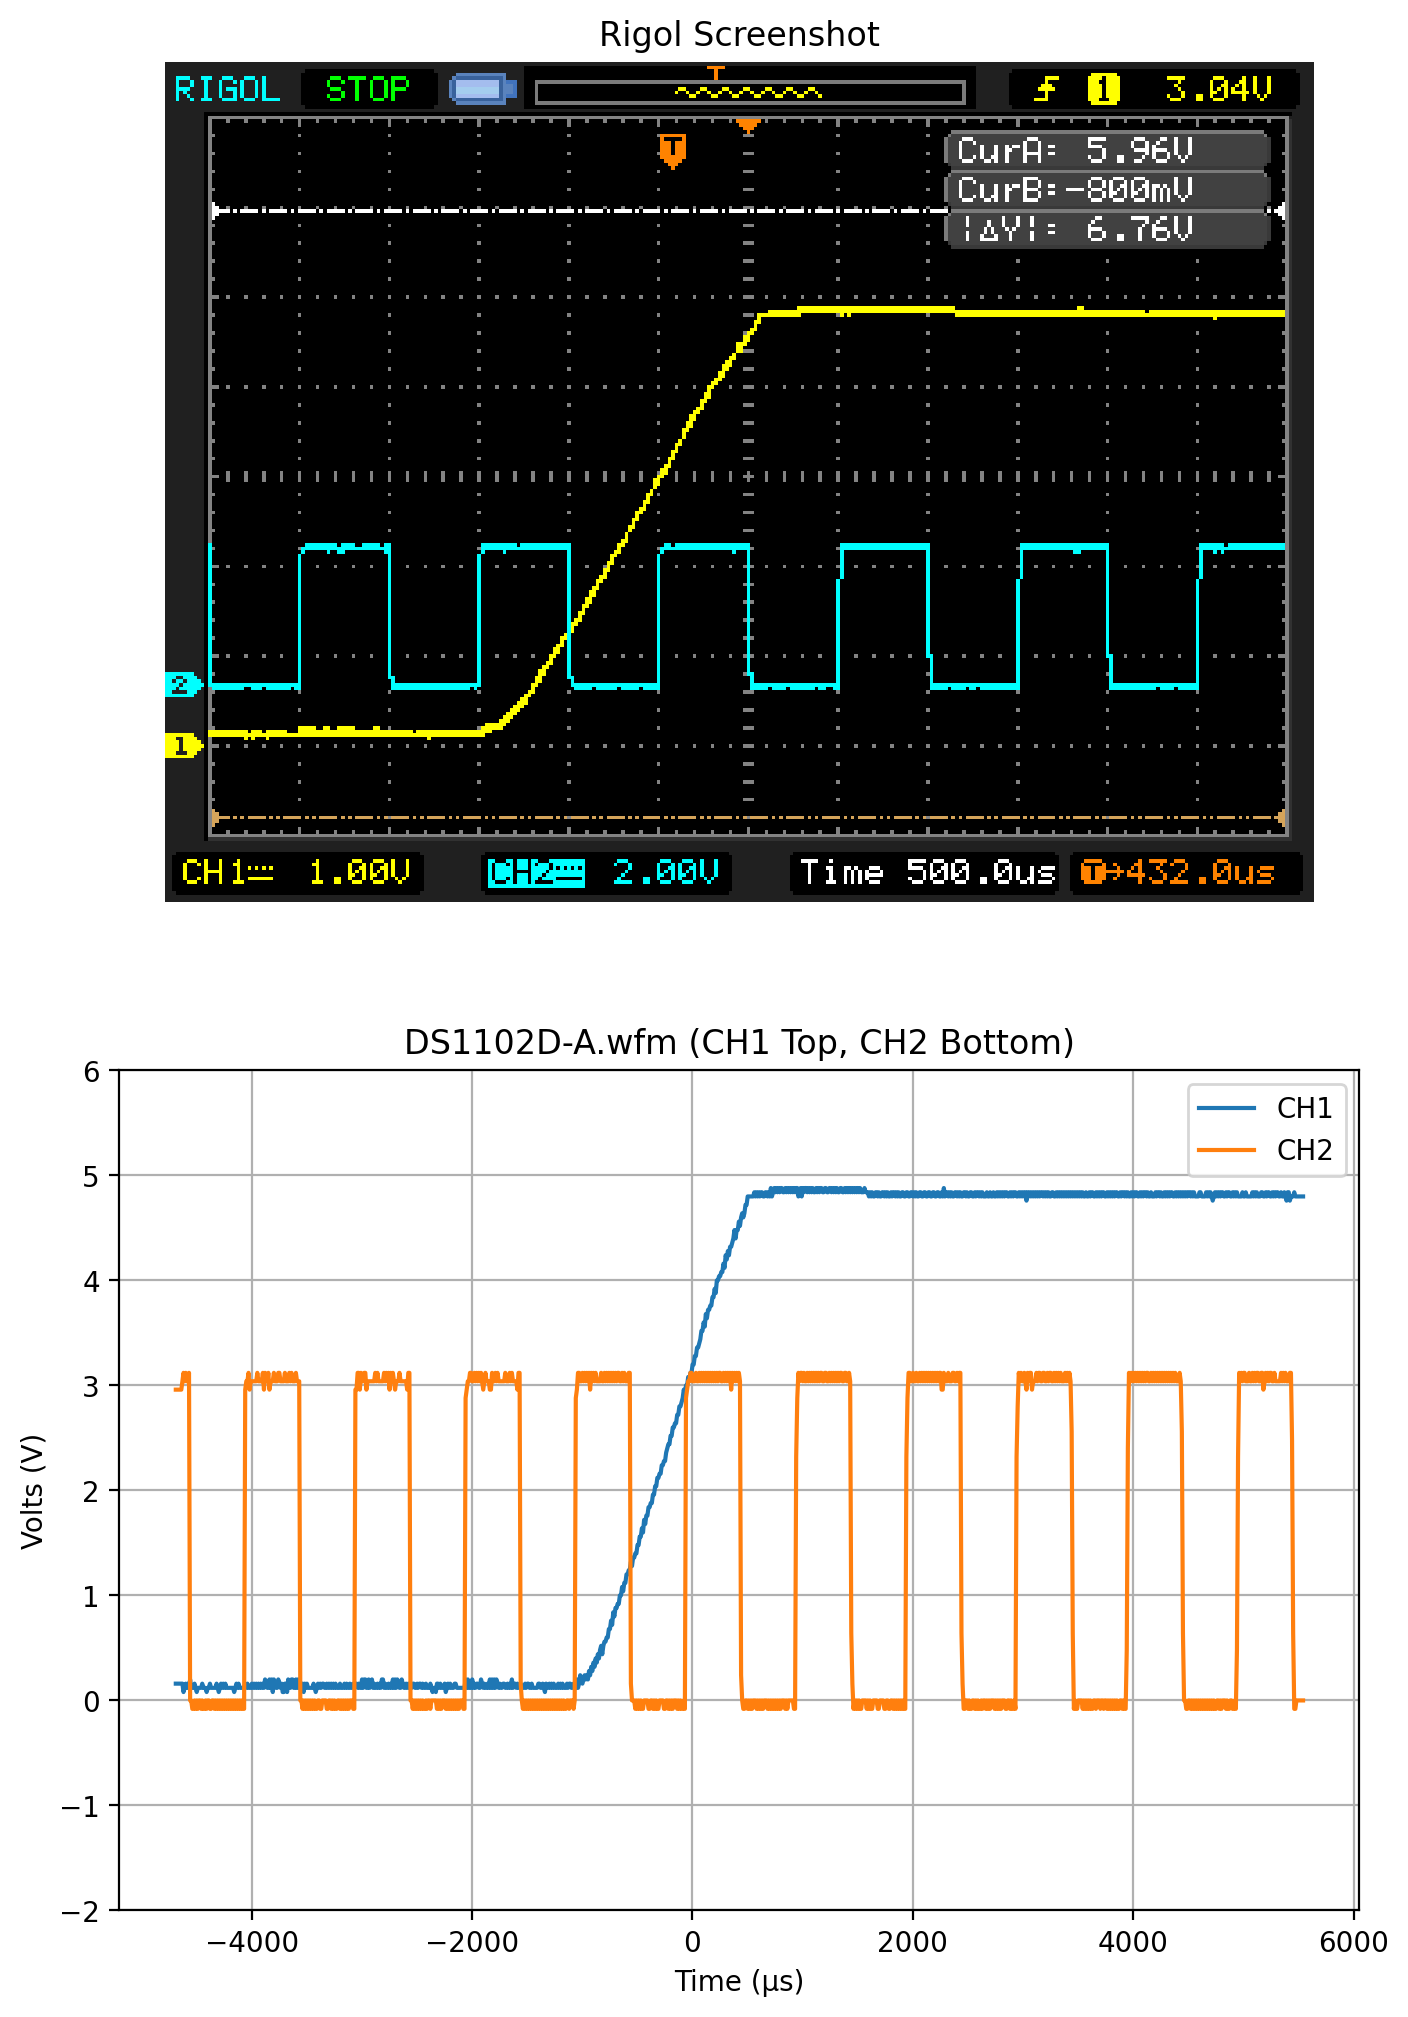

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/wfm/DS1102D-A.wfm?raw=true'


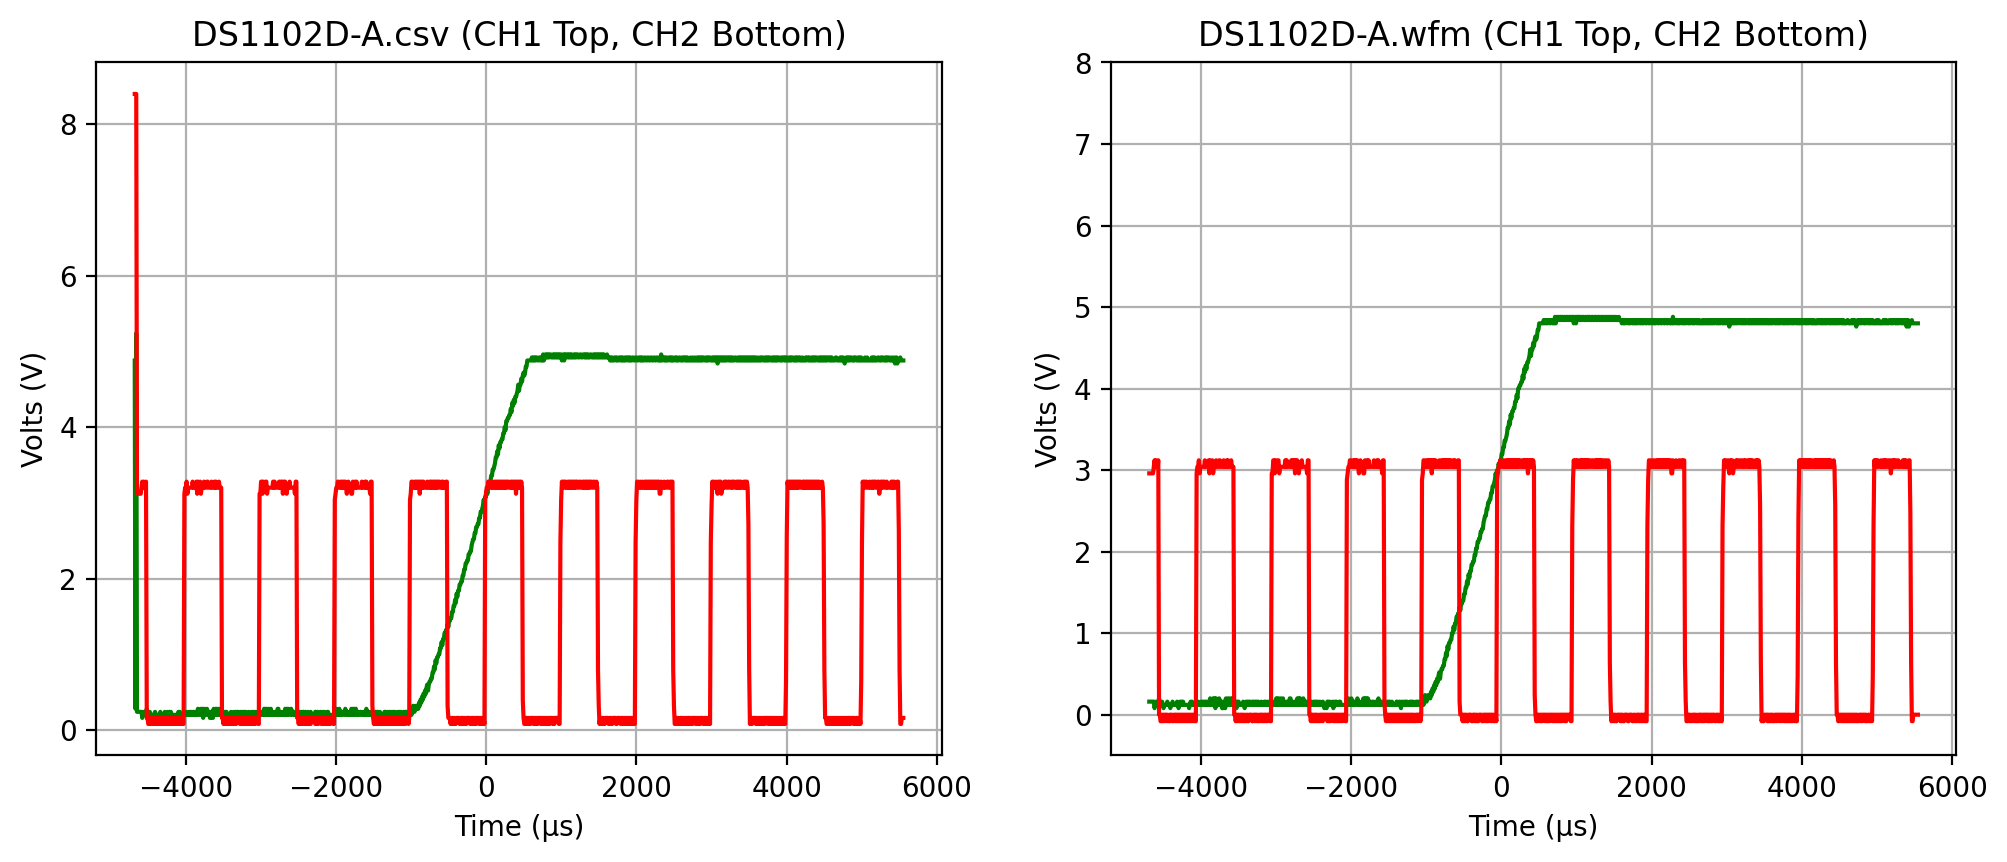

In [28]:
side_by_png("DS1102D-A", ch=[1,2], offset=[0,0])
plt.ylim(-2,6)
plt.show()

side_by_csv("DS1102D-A", ch2_offset=0)
plt.ylim(-0.5,8)
plt.show()

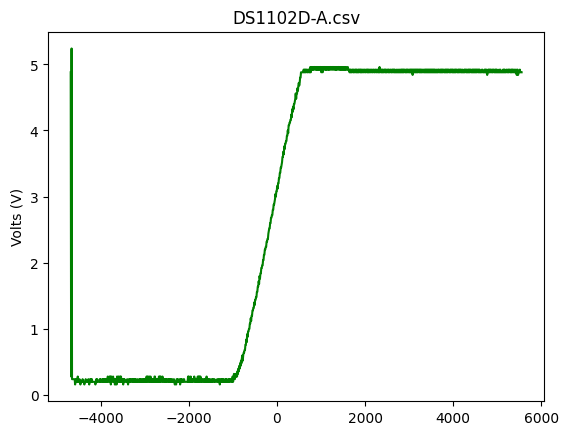

In [6]:
side_by_png("DS1102D-A", ch=[1,2], offset=[0,0])
plt.ylim(-2,6)
plt.show()

filename = "DS1102D-A.csv"

csv_data = np.genfromtxt(repo+filename, delimiter=',', skip_header=2).T

plt.plot(csv_data[0]*1e6,csv_data[1], color='green')
plt.title(filename)
plt.ylabel("Volts (V)")
plt.show()

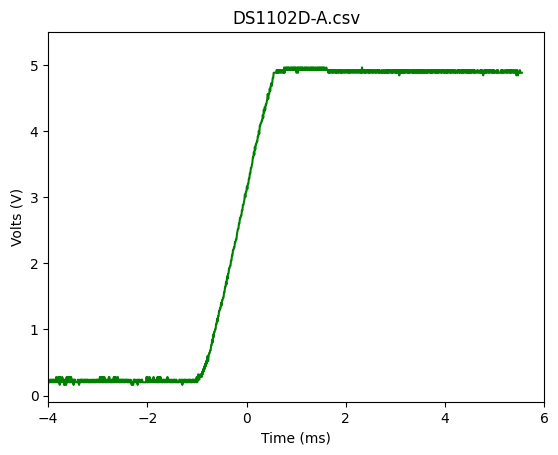

In [7]:
ch = w.channels[0]
plt.plot(csv_data[0]*1e3,csv_data[1], color='green')

plt.title(filename)
plt.ylabel("Volts (V)")
plt.xlabel("Time (ms)")
plt.xlim(-4,6)
plt.show()

### Now for the `.wfm` data

First a textual description.

In [25]:
# raw=true is needed because this is a binary file
wfm_url = "https://github.com/scottprahl/RigolWFM/raw/main/wfm/DS1102D-A.wfm" + "?raw=true"  
w = Wfm.from_url(wfm_url, '1000D')

description = w.describe()
print(description)

    General:
        File Model   = DS1000D
        User Model   = 1000D
        Parser Model = wfm1000d
        Firmware     = unknown
        Filename     = DS1102D-A.wfm
        Channels     = [1, 2]

    Trigger:
        Mode     = edge
        Source   = CH1
        Level    = 3.04  V
        Sweep    = NORMAL
        Coupling = DC
        Derived Level     = 3.20  V

     Channel 1:
         Coupling =  unknown
            Scale =     1.00  V/div
           Offset =    -3.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  500.000 µs/div
           Offset =  432.000 µs
            Delta =   10.000 µs/point
           Points =     1024

         Count    = [        1,        2,        3  ...      1023,     1024]
           Raw    = [      196,      196,      196  ...        80,       80]
           Times  = [-4.688 ms,-4.678 ms,-4.668 ms  ...  5.532 ms, 5.542 ms]
           Volts  = [160.00 mV,160.00 mV,160.00 mV  ...   4.80  V,  4.80  V]

     Ch

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/wfm/DS1102D-A.wfm?raw=true'
